In [1]:
from eval import comparision_histplot, calculate_mean_cov, comparision_histplot_simulation

In [2]:
import numpy as np

In [3]:
training_data_path = "data/latent_gp_data/latent_gp_data.npy"

In [4]:
training_data = np.load(training_data_path)

In [5]:
training_data = training_data

In [6]:
np.shape(training_data)

(1024, 32)

In [7]:
import glob
import os

In [58]:
# Folder path
folder = "/home/yinbinha/adapted_diffusion_model/samples/dfm_latent_gp_data_ts1764706293_seed42"

# Get all batch files sorted by batch number
files = sorted(glob.glob(os.path.join(folder, "sample_batch*.npy")))

# Load and combine
arrays = []
for f in files:
    arr = np.load(f)
    if arr.shape[1] != 32:
        raise ValueError(f"File {f} has unexpected shape {arr.shape}")
    arrays.append(arr)
    
dit = np.concatenate(arrays, axis=0)

In [39]:
dit.shape

(1024, 32)

## Histogram

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def comparision_histplot(stock_i, training_return_data, generated_return_data, 
                        bins_num=50, x_bound=0.1, y_bound=0.1, zoomin_bound=0.05, 
                        filter_range=(-0.2, 0.2), outlier_percentile=1.0):
    """
    Plot histogram with Density Curve (KDE). 
    Outliers are removed ONLY from generated data (training data is assumed clean).
    """
    
    # 1. Extract data
    gen_data = generated_return_data[:, stock_i]
    train_data = training_return_data[:, stock_i]

    # 2. Outlier Removal (Generated Data Only)
    if filter_range is not None:
        lower, upper = filter_range
        gen_data_clean = gen_data[(gen_data >= lower) & (gen_data <= upper)]
        print(f"--- Filtering Data [{lower}, {upper}] ---")
        print(f"Kept {len(gen_data_clean)} Generated samples and {len(train_data)} Training samples.")
    else:
        gen_data_clean = gen_data

    # 3. Print Statistics (Min/Max restored)
    # Note: Printing stats of the data actually being plotted (cleaned gen vs raw train)
    print("\nStatistics:")
    print("Generated Samples: Min {:.4f}, Max {:.4f}, Mean {:.4f}, Var {:.4f}".format(
        gen_data_clean.min(), gen_data_clean.max(), gen_data_clean.mean(), gen_data_clean.var()))
    
    print("Training Samples:  Min {:.4f}, Max {:.4f}, Mean {:.4f}, Var {:.4f}".format(
        train_data.min(), train_data.max(), train_data.mean().item(), train_data.var().item()))

    # 4. Create figure
    fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=400)
    
    # --- Plot Generated Data ---
    sns.histplot(ax=axes[0], data=gen_data_clean, bins=bins_num, alpha=0.5,
                stat="proportion", color="C0", label="Generated",
                kde=True, line_kws={'linewidth': 2, 'linestyle': '-'})
    
    # Calculate bin edges from training data to ensure consistent alignment
    bin_edges = np.histogram(train_data, bins=bins_num, density=False)[1]
    
    # --- Plot Training Data ---
    sns.histplot(ax=axes[1], data=train_data, bins=bin_edges, alpha=0.5,
                stat="proportion", color="C2", label="Training",
                kde=True, line_kws={'linewidth': 2, 'linestyle': '-'})

    # 5. Configure axes
    for ax in axes:
        ax.set_xlim(-x_bound, x_bound)
        ax.tick_params(axis='x', labelsize=12)
        ax.set_ylim(0, y_bound)
        ax.set_yticks(np.linspace(0, y_bound, 4))
        ax.tick_params(axis='y', labelsize=12)
        ax.set_ylabel("Frequency", fontsize=12)
        ax.legend(fontsize=12, loc='upper right')
        
        # Border style
        for spine in ax.spines.values():
            spine.set_color("black")
            spine.set_linewidth(1)

    # 6. Zoom-in Effect
    if zoomin_bound > 0:
        def custom_formatter(x, pos):
            return f"{x:.2f}"

        for ax in axes:
            axins = ax.inset_axes([0.1, 0.4, 0.28, 0.5])
            
            is_gen = (ax == axes[0])
            # Select data: Cleaned Gen data vs Raw Train data
            data_zoom = gen_data_clean if is_gen else train_data
            bins_zoom = bins_num if is_gen else bin_edges
            color_zoom = "C0" if is_gen else "C2"

            sns.histplot(ax=axins, data=data_zoom, bins=bins_zoom, alpha=0.5,
                        color=color_zoom, stat="proportion",
                        kde=True, line_kws={'linewidth': 1.5})
            
            axins.set_xlim(-zoomin_bound, zoomin_bound)
            axins.set_ylim(0, y_bound) 
            axins.set_yticks([])
            axins.set_ylabel("")
            axins.yaxis.set_major_formatter(plt.FuncFormatter(custom_formatter))
            
            for spine in axins.spines.values():
                spine.set_linestyle((0, (5, 4, 1, 4)))
                spine.set_linewidth(1)

    plt.tight_layout()
    plt.show()
    
    return bin_edges

--- Filtering Data [-10, 10] ---
Kept 46 Generated samples and 1024 Training samples.

Statistics:
Generated Samples: Min -8.3402, Max 9.2741, Mean 1.4007, Var 14.5819
Training Samples:  Min -4.7044, Max 4.5814, Mean -0.0157, Var 2.0962


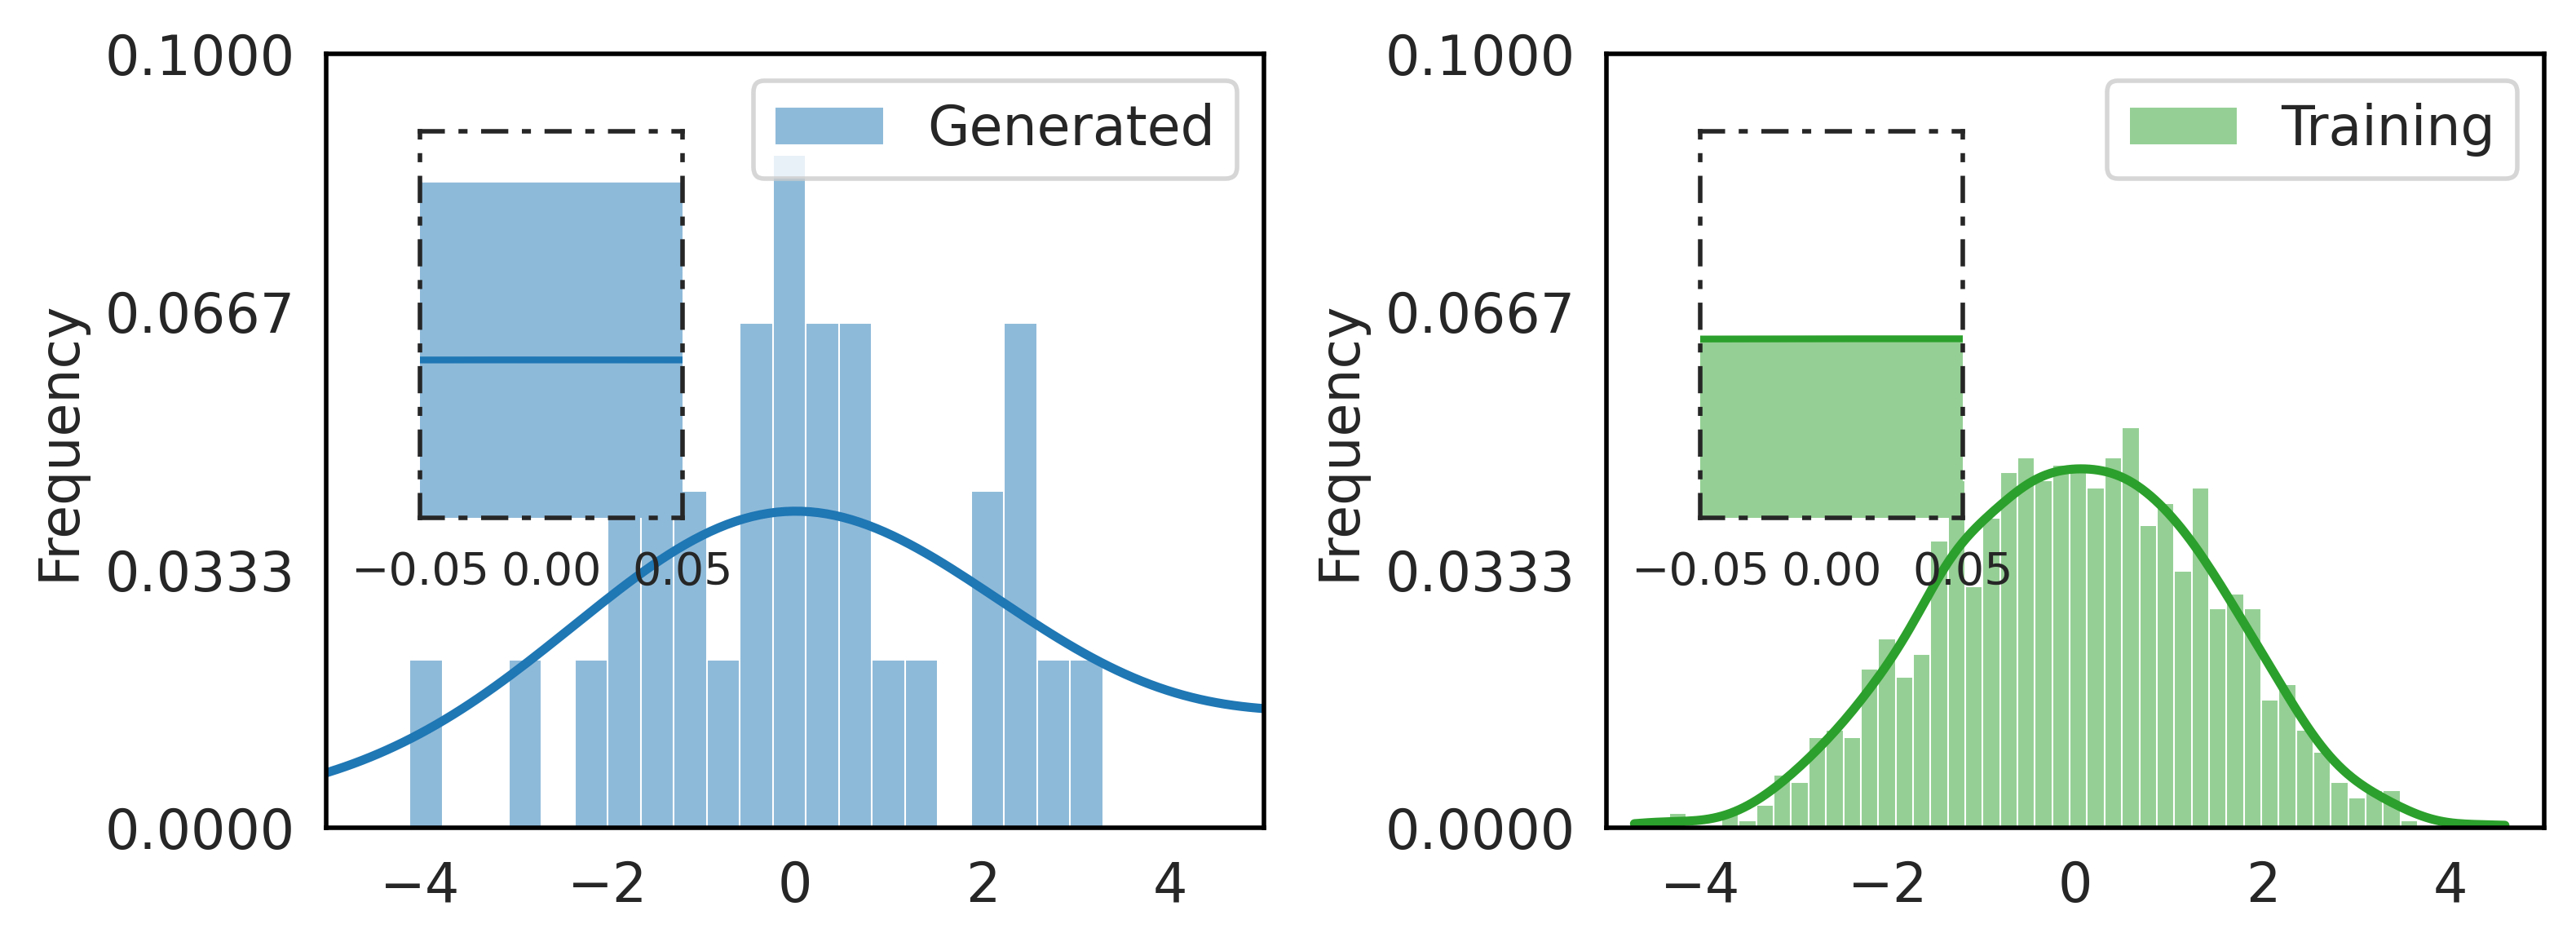

array([-4.70441648, -4.51870043, -4.33298439, -4.14726835, -3.96155231,
       -3.77583627, -3.59012023, -3.40440419, -3.21868814, -3.0329721 ,
       -2.84725606, -2.66154002, -2.47582398, -2.29010794, -2.1043919 ,
       -1.91867586, -1.73295981, -1.54724377, -1.36152773, -1.17581169,
       -0.99009565, -0.80437961, -0.61866357, -0.43294752, -0.24723148,
       -0.06151544,  0.1242006 ,  0.30991664,  0.49563268,  0.68134872,
        0.86706476,  1.05278081,  1.23849685,  1.42421289,  1.60992893,
        1.79564497,  1.98136101,  2.16707705,  2.3527931 ,  2.53850914,
        2.72422518,  2.90994122,  3.09565726,  3.2813733 ,  3.46708934,
        3.65280538,  3.83852143,  4.02423747,  4.20995351,  4.39566955,
        4.58138559])

In [25]:
comparision_histplot(
    stock_i=0, 
    training_return_data=training_data, 
    generated_return_data=dit, 
    filter_range=(-10, 10),
    x_bound=5
)

## QQ-plot

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def comparison_qqplot(stock_i, training_return_data, generated_return_data, filter_range=(-2, 2), zoomin_bound=0.1):
    """
    Plot Q-Q comparison with a Zoom-in inset around the origin (0,0).
    
    Args:
        zoomin_bound (float): The +/- limit for the zoomed-in view (e.g., 0.05 for +/-5% returns).
    """
    
    # 1. Extract data
    gen_data = generated_return_data[:, stock_i]
    train_data = training_return_data[:, stock_i]

    # 1.1. Apply Hard Filter (Keep only data between -0.2 and 0.2)
    if filter_range is not None:
        min_cut, max_cut = filter_range
        
        # Filter Generated
        gen_mask = (gen_data >= min_cut) & (gen_data <= max_cut)
        gen_data = gen_data[gen_mask]
        
        # Filter Training
        train_mask = (train_data >= min_cut) & (train_data <= max_cut)
        train_data = train_data[train_mask]
        
        print(f"--- Filtering Data [{min_cut}, {max_cut}] ---")
        print(f"Kept {len(gen_data)} Generated samples and {len(train_data)} Training samples.")

    # 2. Print Statistics
    print("\nStatistics:")
    print("Generated: Min {:.4f}, Max {:.4f}, Mean {:.4f}, Var {:.4f}".format(
        gen_data.min(), gen_data.max(), gen_data.mean(), gen_data.var()))
    
    print("Training:  Min {:.4f}, Max {:.4f}, Mean {:.4f}, Var {:.4f}".format(
        train_data.min(), train_data.max(), train_data.mean().item(), train_data.var().item()))

    # 3. Calculate Quantiles
    quantiles = np.linspace(0, 100, 1000)
    q_train = np.percentile(train_data, quantiles)
    q_gen = np.percentile(gen_data, quantiles)

    # Determine common limits for the main square plot
    min_val = min(q_train.min(), q_gen.min())
    max_val = max(q_train.max(), q_gen.max())
    buffer = (max_val - min_val) * 0.05
    lims = [min_val - buffer, max_val + buffer]

    # 4. Create Figure
    fig, ax = plt.subplots(figsize=(6, 6), dpi=400)
    
    # --- Main Plot ---
    ax.scatter(q_train, q_gen, alpha=0.6, s=15, color="C0", label="Quantiles", edgecolor='none')
    ax.plot(lims, lims, 'k--', alpha=0.7, label="Perfect Match") # 45-degree line

    # Main Axes Configuration
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Training Data Quantiles", fontsize=12)
    ax.set_ylabel("Generated Data Quantiles", fontsize=12)
    ax.set_title(f"Q-Q Plot: Stock {stock_i}", fontsize=14)
    ax.legend(loc='upper left', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1)

    # # --- Zoom-in Inset ---
    # # Place inset in bottom-right corner (usually empty in Q-Q plots)
    # axins = ax.inset_axes([0.55, 0.05, 0.4, 0.4]) 
    
    # # Plot data on inset
    # axins.scatter(q_train, q_gen, alpha=0.8, s=20, color="C0", edgecolor='none')
    # axins.plot(lims, lims, 'k--', alpha=0.7) # 45-degree line
    
    # # Set Zoom Limits (around 0)
    # axins.set_xlim(-zoomin_bound, zoomin_bound)
    # axins.set_ylim(-zoomin_bound, zoomin_bound)
    
    # # Style the Inset
    # axins.grid(True, linestyle=':', alpha=0.5)
    # axins.set_title(f"Zoom (±{zoomin_bound})", fontsize=10)
    
    # # Add connector lines pointing to the zoom area
    # indicating that we are zooming in on the center
    # ax.indicate_inset_zoom(axins, edgecolor="black", alpha=0.4)
    
    # # Custom border for inset to make it pop
    # for spine in axins.spines.values():
    #     spine.set_linestyle('--')
    #     spine.set_color('gray')

    plt.tight_layout()
    plt.show()

--- Filtering Data [-100, 100] ---
Kept 1024 Generated samples and 1024 Training samples.

Statistics:
Generated: Min -3.7998, Max 3.5565, Mean -0.0611, Var 1.4778
Training:  Min -4.2899, Max 4.9014, Mean -0.0147, Var 1.8844


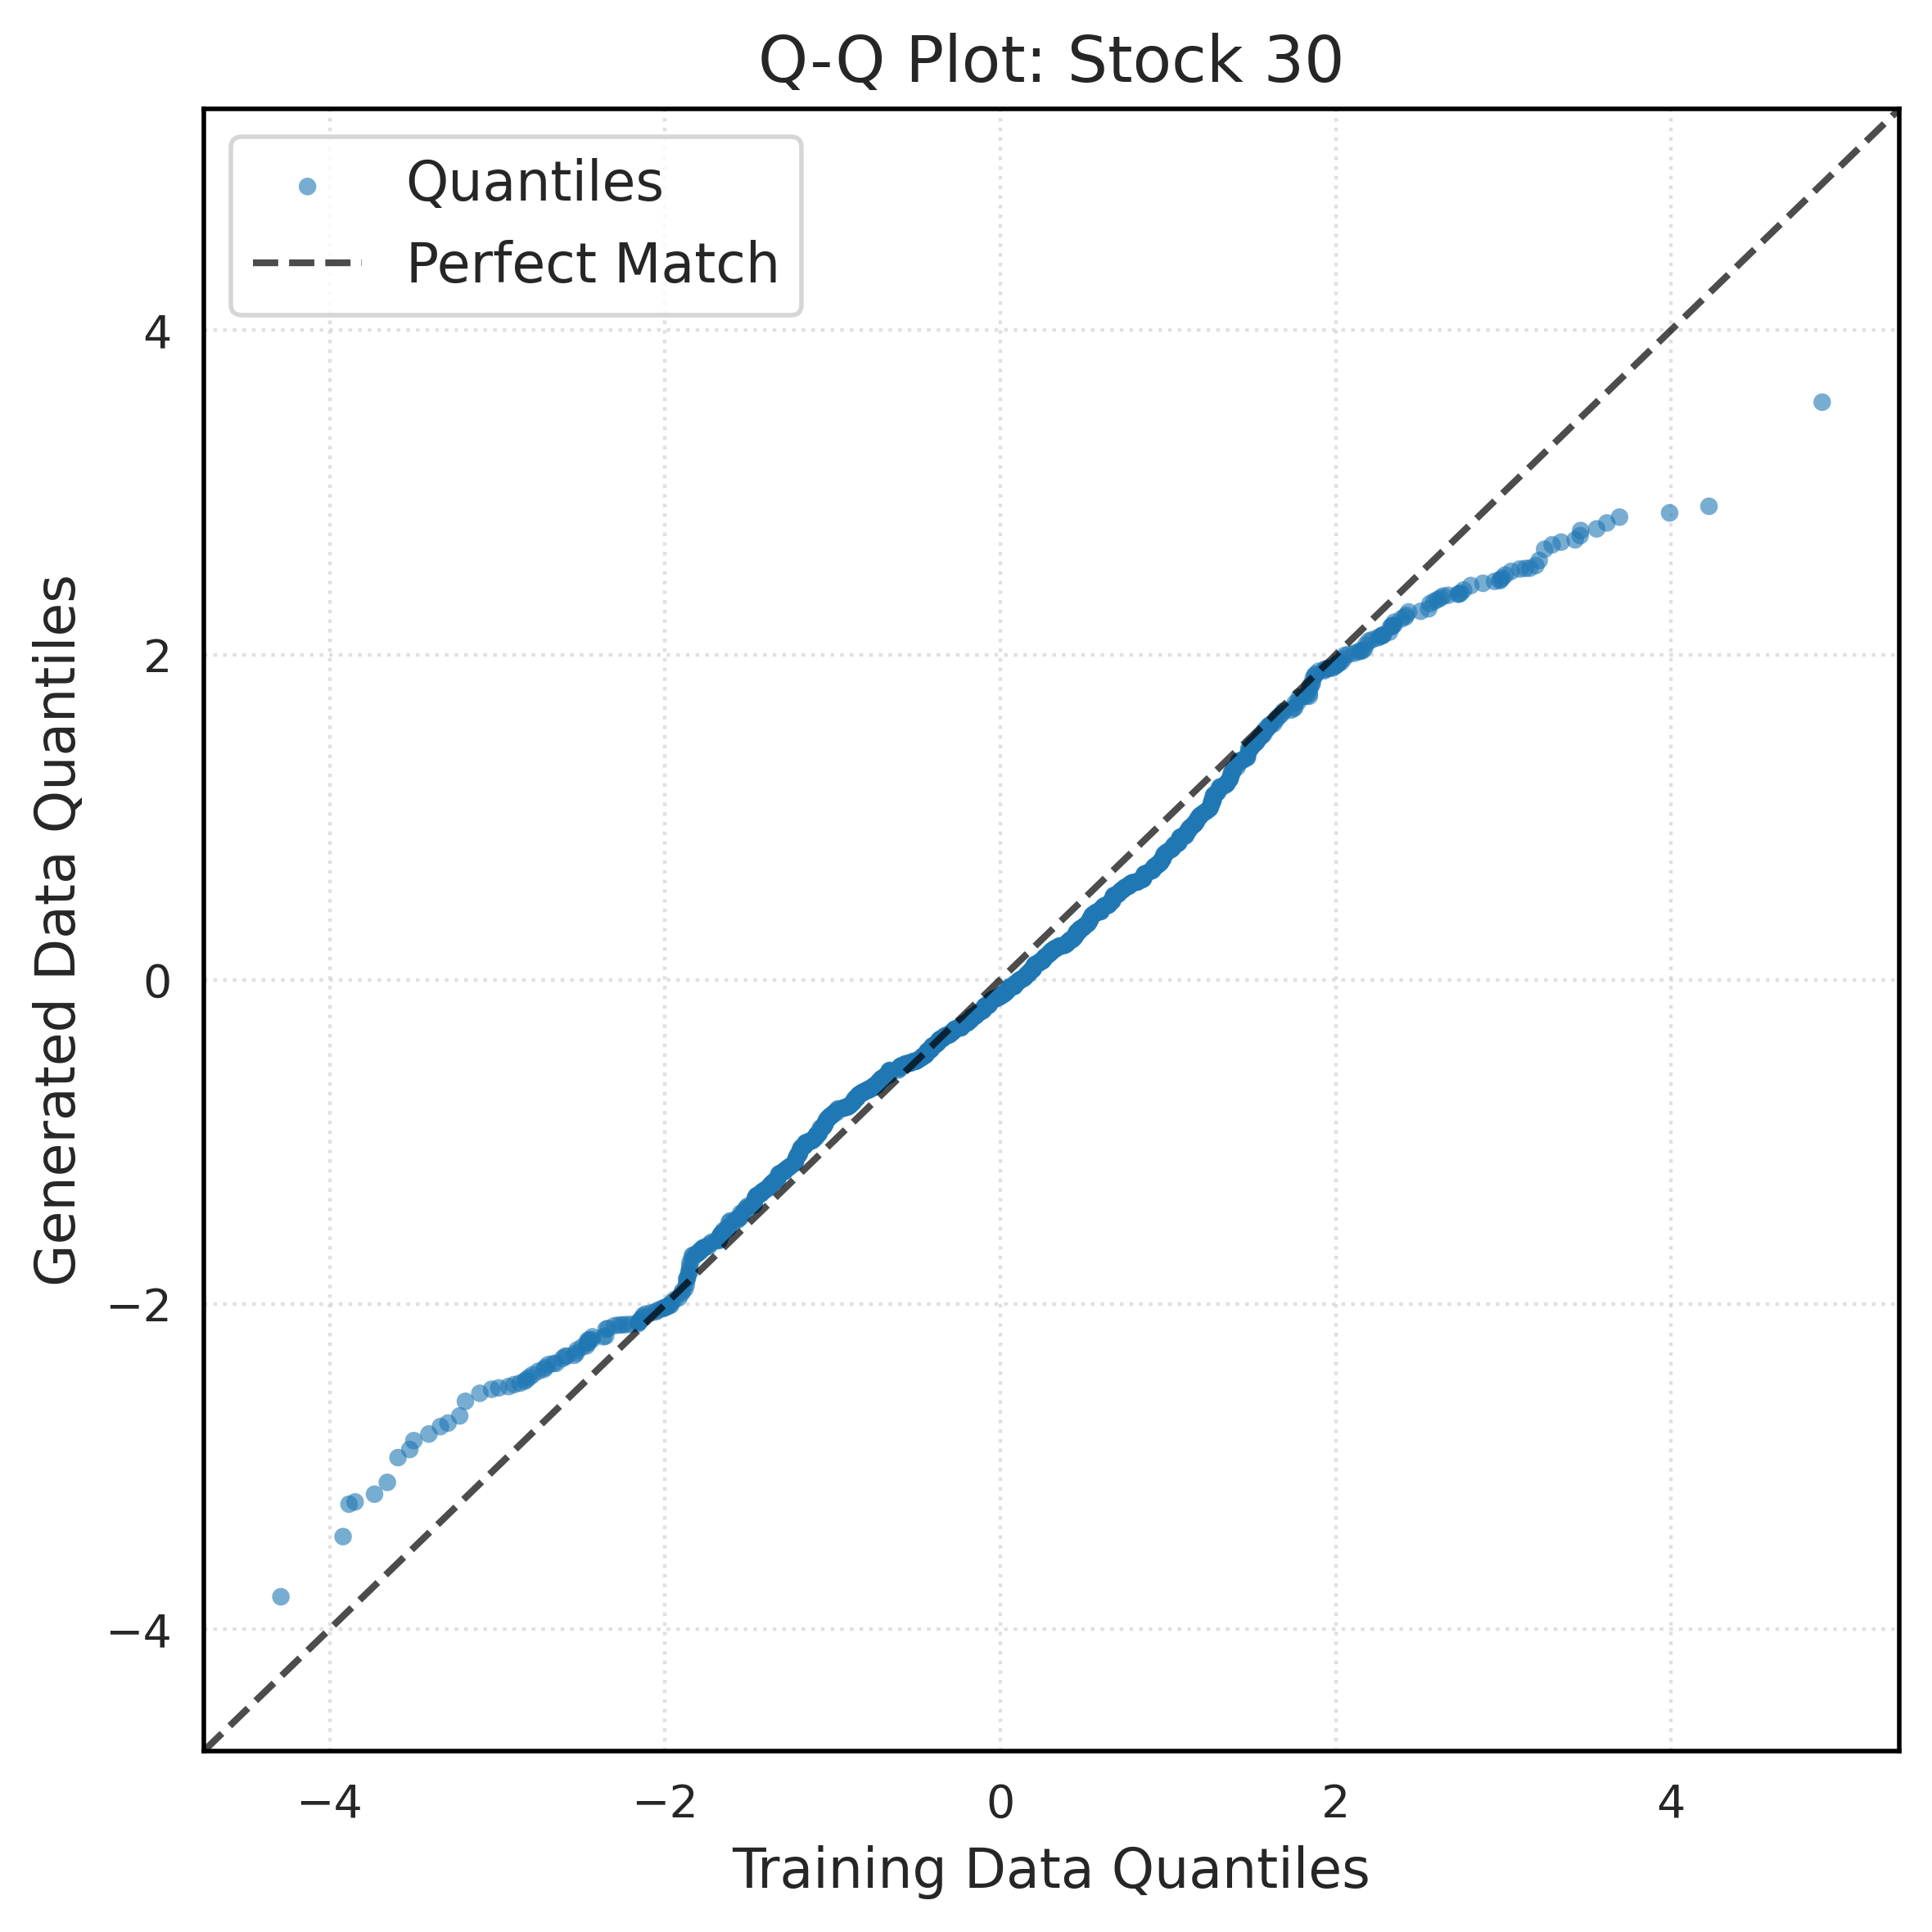

In [63]:
comparison_qqplot(30, training_return_data=training_data, generated_return_data=dit, filter_range=(-100, 100))

## ARMA model

In [15]:
def generate_arma_scratch(ar_coefs, ma_coefs, n_samples, sigma=1.0, burn_in=100):
    """
    ar_coefs: list of phi values [phi_1, phi_2...]
    ma_coefs: list of theta values [theta_1, theta_2...]
    """
    p = len(ar_coefs)
    q = len(ma_coefs)
    total_n = n_samples + burn_in
    
    # Initialize arrays
    X = np.zeros(total_n)
    epsilon = np.random.normal(0, sigma, total_n)
    
    # Iterate
    for t in range(max(p, q), total_n):
        # AR component: dot product of past X and AR coefs
        # We reverse the slice of X to match coefs order (t-1, t-2...)
        ar_term = np.dot(ar_coefs, X[t-p:t][::-1])
        
        # MA component: dot product of past errors and MA coefs
        ma_term = np.dot(ma_coefs, epsilon[t-q:t][::-1])
        
        X[t] = ar_term + ma_term + epsilon[t]
        
    # Discard burn-in
    return X[burn_in:]


In [326]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess

# # --- 1. Create "Mystery" Real Data ---
# # Hidden Truth: AR(1) with phi=0.75, MA(1) with theta=0.65
# np.random.seed(42)
# ar = np.array([1, -0.75]) 
# ma = np.array([1, 0.65])
# mystery_process = ArmaProcess(ar, ma)
# mystery_data = mystery_process.generate_sample(nsample=1000)

# --- 2. Fit the Model ---
# We assume we don't know p and q, but let's guess (1, 0, 1)
# order = (p, d, q) -> d=0 means ARMA
model = ARIMA(training_data[10,:], order=(10, 0, 5))
model_fit = model.fit()

# --- 3. Review Results ---
print(model_fit.summary())

# Extract estimated parameters
phi_est = model_fit.polynomial_ar # ar.L1
theta_est = model_fit.polynomial_ma # ma.L1

# print(f"Estimation ---")
print("Estimated AR", phi_est)
print("Estimated MA", theta_est)

/home/yinbinha/]/envs/adapted/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/yinbinha/]/envs/adapted/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   32
Model:                ARIMA(10, 0, 5)   Log Likelihood                  58.289
Date:                Wed, 26 Nov 2025   AIC                            -82.579
Time:                        13:29:07   BIC                            -57.661
Sample:                             0   HQIC                           -74.319
                                 - 32                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.006      0.031      0.975      -0.011       0.012
ar.L1         -0.0933      4.077     -0.023      0.982      -8.085       7.898
ar.L2          0.1526      3.147      0.048      0.9

/home/yinbinha/]/envs/adapted/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


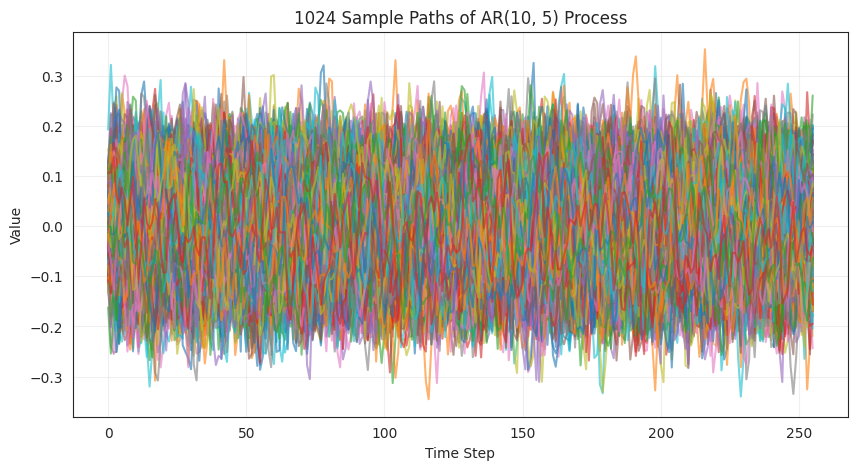

In [212]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
np.random.seed(42)

# 1. Setup Parameters (Example: AR(1) with Phi=0.9)
# ar_params = np.random.randn(10)
# ma_params = np.random.randn(5)
# ar = np.array([1, 0.13271238,  0.09034768,  0.1350643,  -0.45685479,  0.10674823,
#   0.0064077,   0.15781995,  0.76351815,  0.0506077,   0.12726754])
# ma = np.array([1.,         -0.13331379, -0.00358175, -0.01011468, -0.63519146,  0.1808411 ])

ar = np.array([1, -0.5])
ma = np.array([1, 0.5])

# 2. Generate Multiple Paths
# nsample=(Length, Number of Paths)
T = 256  # Time steps
N = 1024   # Number of independent paths
process = ArmaProcess(ar, ma)

# This returns a shape (100, 10) array
paths_matrix = process.generate_sample(nsample=(T, N), scale=0.05)

# 3. Visualization
plt.figure(figsize=(10, 5))
plt.plot(paths_matrix, alpha=0.6) # Plots all columns automatically
plt.title(f"{N} Sample Paths of AR(10, 5) Process")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.show()

# 4. Save data
np.save('./data/ARMA/AR10MA5.npy', paths_matrix.T)

In [173]:
# --- 1. Theoretical Ground Truth ---
# Remember statsmodels sign convention
ar_params = ar
ma_params = ma
process = ArmaProcess(ar_params, ma_params)

# Get theoretical curves (up to lag 20)
theo_acf = process.acf(lags=40)
theo_pacf = process.pacf(lags=16)

In [174]:
theo_acf

array([1.00000000e+00, 7.14285714e-01, 3.57142857e-01, 1.78571429e-01,
       8.92857143e-02, 4.46428571e-02, 2.23214286e-02, 1.11607143e-02,
       5.58035714e-03, 2.79017857e-03, 1.39508929e-03, 6.97544643e-04,
       3.48772321e-04, 1.74386161e-04, 8.71930804e-05, 4.35965402e-05,
       2.17982701e-05, 1.08991350e-05, 5.44956752e-06, 2.72478376e-06,
       1.36239188e-06, 6.81195940e-07, 3.40597970e-07, 1.70298985e-07,
       8.51494925e-08, 4.25747463e-08, 2.12873731e-08, 1.06436866e-08,
       5.32184328e-09, 2.66092164e-09, 1.33046082e-09, 6.65230410e-10,
       3.32615205e-10, 1.66307603e-10, 8.31538013e-11, 4.15769007e-11,
       2.07884503e-11, 1.03942252e-11, 5.19711258e-12, 2.59855629e-12])

In [175]:
theo_pacf

array([ 1.00000000e+00,  7.14285714e-01, -3.12500000e-01,  1.51515152e-01,
       -7.51879699e-02,  3.75234522e-02, -1.87529301e-02,  9.37536623e-03,
       -4.68754578e-03,  2.34375572e-03, -1.17187572e-03,  5.85937589e-04,
       -2.92968761e-04,  1.46484376e-04, -7.32421877e-05,  3.66210938e-05])

In [240]:
from statsmodels.tsa.stattools import acf, pacf

# --- 2. Empirical (Generated) ---
# Compute ACF/PACF for every single path
gen_acfs = []
gen_pacfs = []

for row in dit:
    gen_acfs.append(acf(row, nlags=39, fft=True))
    gen_pacfs.append(pacf(row, nlags=15))
    
gen_acfs = np.array(gen_acfs)
gen_pacfs = np.array(gen_pacfs)

In [241]:
# Mean and Confidence Interval (1 std dev)
mean_acf = gen_acfs.mean(axis=0)
std_acf = gen_acfs.std(axis=0)

mean_pacf = gen_pacfs.mean(axis=0)
std_pacf = gen_pacfs.std(axis=0)

In [242]:
mean_acf

array([ 1.00000000e+00, -3.07865791e-03,  4.57214209e-04, -9.40815120e-04,
       -2.17075600e-03, -2.96084755e-03,  3.11647437e-03, -8.45672709e-05,
       -8.07008029e-03, -3.78596016e-03, -5.73920921e-03, -2.50219597e-03,
       -1.33684122e-03, -1.78507139e-03, -5.75240312e-03, -4.85910616e-03,
       -1.15796056e-02,  6.05110211e-03, -1.66532340e-03, -5.61432336e-03,
        3.18380018e-03, -1.59065074e-04, -8.17256224e-05, -4.65429826e-03,
       -5.66046922e-03, -3.65797417e-03,  4.50430555e-04,  3.28613481e-03,
       -3.15500711e-03, -2.42529969e-04, -4.32726075e-03, -1.93268196e-03,
       -7.28730445e-03, -5.22996387e-04, -2.96106312e-03, -3.77759235e-03,
       -3.77861208e-04,  4.48878570e-03, -7.69424391e-03, -5.13050213e-03])

In [243]:
mean_pacf

array([ 1.00000000e+00, -3.09073108e-03, -3.24035342e-03, -5.26830860e-04,
       -6.51865690e-03, -2.43999603e-03, -1.65520452e-03,  5.41177717e-04,
       -1.26457260e-02, -2.89096544e-03, -9.59006734e-03, -2.40178809e-03,
       -8.01081461e-03, -3.46258256e-03, -1.12467662e-02, -6.65698217e-03])

In [194]:
# --- 2. Empirical (Generated) ---
# Compute ACF/PACF for every single path
train_acfs = []
train_pacfs = []

for row in paths_matrix.T:
    train_acfs.append(acf(row, nlags=39, fft=True))
    train_pacfs.append(pacf(row, nlags=15))
    
train_acfs = np.array(train_acfs)
train_pacfs = np.array(train_pacfs)

In [195]:
# Mean and Confidence Interval (1 std dev)
train_mean_acf = train_acfs.mean(axis=0)
train_std_acf = train_acfs.std(axis=0)

train_mean_pacf = train_pacfs.mean(axis=0)
train_std_pacf = train_pacfs.std(axis=0)

In [196]:
train_mean_acf

array([ 1.        ,  0.70321871,  0.33631222,  0.15621593,  0.06811838,
        0.0248359 ,  0.00364087, -0.00775434, -0.01347675, -0.01437602,
       -0.01366596, -0.01403148, -0.0142934 , -0.01377419, -0.01396328,
       -0.01586749, -0.01801154, -0.01821108, -0.01681325, -0.01674192,
       -0.0168844 , -0.01634501, -0.01457276, -0.01274657, -0.01245639,
       -0.01120561, -0.0094567 , -0.00931992, -0.01060762, -0.01157754,
       -0.01011024, -0.00878303, -0.01055435, -0.01308743, -0.01427186,
       -0.01352194, -0.01302613, -0.01320821, -0.01242113, -0.01177692])

In [197]:
train_mean_pacf

array([ 1.00000000e+00,  7.05976434e-01, -3.20699431e-01,  1.47498159e-01,
       -8.41467105e-02,  3.35496174e-02, -2.80845909e-02,  2.84940356e-03,
       -1.25180342e-02, -6.84679103e-04, -1.03467233e-02, -3.96736336e-03,
       -7.32874137e-03, -2.95611815e-03, -1.05944060e-02, -8.48290062e-03])

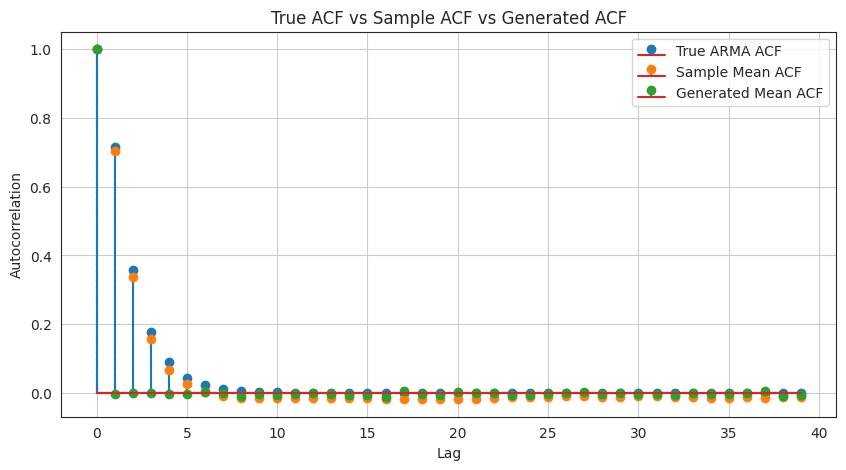

In [244]:
import matplotlib.pyplot as plt

lags_range = np.arange(len(theo_acf))

plt.figure(figsize=(10, 5))

# True ACF (solid line)
# plt.plot(lags_range, theo_acf, label="True ARMA ACF", linewidth=2)
markerline, stemlines, baseline = plt.stem(lags_range, theo_acf, label="True ARMA ACF", linefmt="-")


# Mean generated ACF (dashed line)
# plt.plot(lags_range, train_mean_acf, label="Sample Mean ACF", linestyle='--', linewidth=2)
markerline, stemlines, baseline = plt.stem(lags_range, train_mean_acf, label="Sample Mean ACF", linefmt="-.")

# plt.plot(lags_range, mean_acf, label="Generated Mean ACF", linestyle='-.', linewidth=2)
markerline, stemlines, baseline = plt.stem(lags_range, mean_acf, label="Generated Mean ACF", linefmt=":")



# # Optional: 1 std confidence band around generated ACF
# plt.fill_between(
#     lags_range,
#     mean_acf - std_acf,
#     mean_acf + std_acf,
#     alpha=0.2,
#     label="Generated ACF ± 1 std"
# )

plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("True ACF vs Sample ACF vs Generated ACF")
plt.legend()
plt.grid(True)
plt.show()

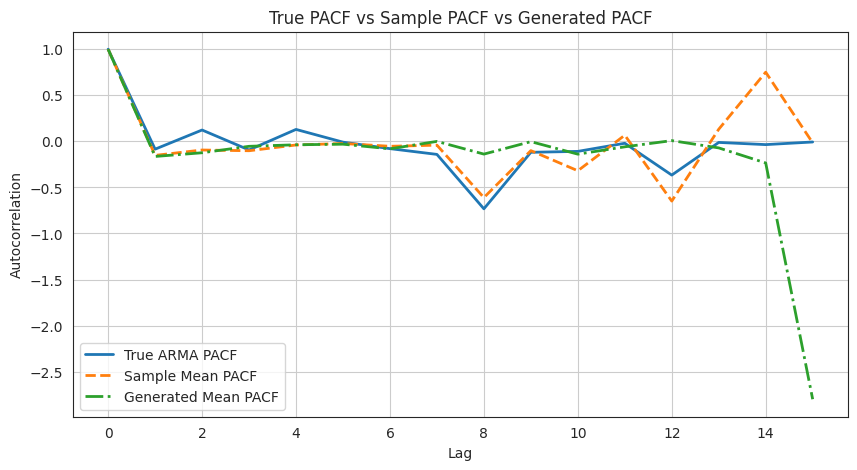

In [30]:
lags_range = np.arange(len(theo_pacf))

plt.figure(figsize=(10, 5))

# True ACF (solid line)
plt.plot(lags_range, theo_pacf, label="True ARMA PACF", linewidth=2)

# Mean generated ACF (dashed line)
plt.plot(lags_range, train_mean_pacf, label="Sample Mean PACF", linestyle='--', linewidth=2)
plt.plot(lags_range, mean_pacf, label="Generated Mean PACF", linestyle='-.', linewidth=2)


# # Optional: 1 std confidence band around generated ACF
# plt.fill_between(
#     lags_range,
#     mean_pacf - std_pacf,
#     mean_pacf + std_pacf,
#     alpha=0.2,
#     label="Generated PACF ± 1 std"
# )

plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("True PACF vs Sample PACF vs Generated PACF")
plt.legend()
plt.grid(True)
plt.show()